In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (precision_score, recall_score, 
                            f1_score, accuracy_score, 
                            confusion_matrix, classification_report)
from collections import Counter
from tqdm.auto import tqdm
from tqdm import tqdm
from torchcam.methods import GradCAM
from torchvision.utils import save_image
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.nn import TransformerEncoder, TransformerEncoderLayer

# трансформер из Hugging Face
from transformers import ViTFeatureExtractor, ViTForImageClassification

C:\Users\vov04\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("Доступен ли GPU:", torch.cuda.is_available()) 
print("Название GPU:", torch.cuda.get_device_name(0))
print("Версия CUDA в PyTorch:", torch.version.cuda)  

Доступен ли GPU: True
Название GPU: NVIDIA GeForce GTX 1650 with Max-Q Design
Версия CUDA в PyTorch: None


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

using device: cuda


In [5]:
folder_path = "E:\\VYZ\\ICONS"
dataset_path = folder_path + "\\icons_dataset_3.csv"
images_path = folder_path + "\\images"
augmented_images_path = folder_path + "\\augmented_dataset.csv"
saved_models_path = folder_path +"\\saved_models"

функция создания ацгментаций для датасета. 

In [6]:
def create_augmented_dataset(source_df, source_img_dir, target_dir, n_augments=5):

    os.makedirs(target_dir, exist_ok=True)
    supported_formats = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    
    augment_transform = transforms.Compose([
        transforms.RandomAffine(degrees=3, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomGrayscale(p=0.1)
    ])
    
    new_rows = []
    
    for _, row in tqdm(source_df.iterrows(), total=len(source_df), desc="Создание аугментированного датасета"):
        img_id = str(row['id'])
        img_path = None
        
        for fmt in supported_formats:
            possible_path = os.path.join(source_img_dir, f"{img_id}{fmt}")
            if os.path.exists(possible_path):
                img_path = possible_path
                break
                
        if not img_path:
            print(f"Изображение {img_id} не найдено, пропускаем")
            continue
            
        ext = os.path.splitext(img_path)[1]
        original_target_path = os.path.join(target_dir, f"{img_id}{ext}")
        shutil.copy2(img_path, original_target_path)
        
        new_row = row.copy()
        new_rows.append(new_row)
        
        img = Image.open(img_path).convert('RGB')
        
        for i in range(n_augments):
            try:
                augmented_img = augment_transform(img)
                new_id = f"aug_{i}_{img_id}"
                new_filename = f"{new_id}{ext}"
                new_path = os.path.join(target_dir, new_filename)
                augmented_img.save(new_path)
                
                new_row = row.copy()
                new_row['id'] = new_id
                new_rows.append(new_row)
                
            except Exception as e:
                print(f"Ошибка при аугментации {img_path}: {e}")
    
    new_df = pd.DataFrame(new_rows)
    
    csv_path = os.path.join(target_dir, "augmented_dataset.csv")
    new_df.to_csv(csv_path, index=False, encoding='utf-8')
    
    print(f"\nСоздан аугментированный датасет в {target_dir}")
    print(f"Всего изображений: {len(new_df)}")
    print(f"Оригинальных: {len(new_df[~new_df['id'].astype(str).str.startswith('aug_')])}")
    print(f"Аугментированных: {len(new_df[new_df['id'].astype(str).str.startswith('aug_')])}")
    print(f"CSV файл сохранен: {csv_path}")
    
    return new_df

#new_df = create_augmented_dataset(df_filtered, "E:\\VYZ\\ICONS\\images", "E:\\VYZ\\ICONS\\augmented_dataset", n_augments=5)

In [7]:
df = pd.read_csv(dataset_path, sep=";", encoding = "utf-8")
df.head()

,id,Название,Реставрация,Размер,Автор,Материал,Персоналии,Уточняющая датировка,Век,Страна,Место хранения,Иконография,Тип изображения,Фрагменты
0,1,Азовская с предстоящими,False,NaN,NaN,"Дерево, левкас, темпера","Саваоф, Спаситель, Богоматерь, ангелы, ап. Пет...",начало,18.0,Россия,"Государственный Исторический музей, Москва",Богоматерь,Ростовое с клеймами,"Азов, Кази-Кермен"
1,2,Акафистная,False,92 x 71 см,Иван Григорьев Марков,"Дерево, темпера","Спаситель, Богоматерь",первая четверть,18.0,Россия,Вологодский государственный историко-архитекту...,Богоматерь,Многофигурное,Богоматерь с Младенцем (Акафистная)
2,3,Аристократуса,False,"57,5 х 43 см",NaN,"Дерево, темпера","Младенец Христос, Богородица",вторая половина,13.0,Византия,"Афон, монастырь Ватопед",Богоматерь,Поясное,"Богоматерь (Аристократуса), Богоматерь (Аристо..."
3,4,Ахтырская,False,123 х 90 см,NaN,"Дерево, темпера","Спаситель, Богородица",Первая четверть,19.0,Россия,"Государственный музей-заповедник ""Ростовский К...",Богоматерь,Поясное,NaN
4,5,Ахтырская,True,33 x 28 см,NaN,"Дерево, левкас, темпера","Спаситель, Богородица, архангел Михаил, первом...",конец,18.0,Россия,Частное собрание М.Б. Миндлина,Богоматерь,Поясное с клеймами,NaN


выявляем количество представителей каждого класса

In [8]:
class_counts = df["Название"].value_counts()
class_counts

Название
Одигитрия                                                                                  102
Никола Чудотворец                                                                           91
Успение                                                                                     87
Рождество Христово                                                                          86
Воскресение Христово - Сошествие во ад                                                      83
                                                                                          ... 
Петр и княгиня Феврония Муромские                                                            1
Богоматерь (из деисусного чина) и Преображение                                               1
Боголюбская, с припадающим святым князем Андреем Боголюбским                                 1
Боголюбская, в молении ростовских чудотворцев                                                1
Боголюбская с припадающими святителем Але

убираем классы с малым количеством примеров 

In [9]:
min_samples = 50
valid_classes = class_counts[class_counts >= min_samples].index
df_filtered = df[df["Название"].isin(valid_classes)]
df_filtered["Название"].value_counts()

Название
Одигитрия                                 102
Никола Чудотворец                          91
Успение                                    87
Рождество Христово                         86
Воскресение Христово - Сошествие во ад     83
Владимирская                               80
Благовещение                               72
Распятие Господне                          67
Спас Нерукотворный                         61
Спас Вседержитель                          59
Пантократор                                56
Name: count, dtype: int64

кодируем метки (названия) тех классов, что остались

In [10]:
label_encoder = LabelEncoder()
df_filtered["label"] = label_encoder.fit_transform(df_filtered["Название"])
NUM_classes = len(label_encoder.classes_)
print(f"Number of classes: {NUM_classes}")
df_filtered.head()

Number of classes: 11


C:\Users\vov04\AppData\Local\Temp\ipykernel_33252\2949522722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["label"] = label_encoder.fit_transform(df_filtered["Название"])


,id,Название,Реставрация,Размер,Автор,Материал,Персоналии,Уточняющая датировка,Век,Страна,Место хранения,Иконография,Тип изображения,Фрагменты,label
156,165,Владимирская,False,"30,3 х 24,8",NaN,"Дерево, левкас, темпера",NaN,середина,16.0,Россия,Частное собрание А.Ш.,Богоматерь,Поясное,NaN,1
157,166,Владимирская,False,118 х 92 см,NaN,"Дерево, темпера","Спаситель, Богородица",1564 г.,16.0,Россия,Ярославский государственный историко-архитекту...,Богоматерь,Поясное,Афанасий Александрийский и прп. Сергий,1
158,167,Владимирская,False,"102,2 х 69,5 см",Андрей Рублев,"Дерево, темпера","Спаситель, Богоматерь",1395 или 1408 гг.,14.0,Россия,Государственный Владимиро-Суздальский историко...,Богоматерь,Поясное,"Спаситель и Богоматерь (Владимирская), Богомат...",1
159,168,Владимирская,False,37 х 26 см,NaN,"Дерево, темпера","Богоматерь, Младенец-Христос",первая половина,15.0,Россия,Государственный Владимиро-Суздальский историко...,Богоматерь,Поясное,Спаситель и Богоматерь (Владимирская),1
160,169,Владимирская,False,32 х 27 см,NaN,"Дерево, темпера","Младенец-Христос, Богородица",NaN,15.0,Россия,Государственный Владимиро-Суздальский историко...,Богоматерь,Поясное,Спаситель и Богоматерь (Владимирская),1


аугментируем изображения, которые входят в отфильтрованный датасет

In [11]:
# аугментация (тех классов что остались)
new_df = create_augmented_dataset(df_filtered, images_path, augmented_images_path, n_augments=7)

FileExistsError: [WinError 183] Невозможно создать файл, так как он уже существует: 'E:\\VYZ\\ICONS\\augmented_dataset.csv'

In [12]:
new_df = pd.read_csv(augmented_images_path, sep=",", encoding = "utf-8")

In [13]:
# распределение классов после аугментации
print("\nРаспределение классов в train_df:")
print(new_df['Название'].value_counts())



Распределение классов в train_df:
Название
Одигитрия                                 816
Никола Чудотворец                         728
Успение                                   696
Рождество Христово                        688
Воскресение Христово - Сошествие во ад    664
Владимирская                              640
Благовещение                              576
Распятие Господне                         536
Спас Нерукотворный                        488
Спас Вседержитель                         472
Пантократор                               448
Name: count, dtype: int64


In [14]:
label_encoder = LabelEncoder()
new_df["label"] = label_encoder.fit_transform(new_df["Название"])
NUM_classes = len(label_encoder.classes_)
print(f"Number of classes: {NUM_classes}")

Number of classes: 11


In [15]:
train_df, test_df = train_test_split(df_filtered, test_size=0.3, stratify=df_filtered['label'], random_state=123)
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['label'], random_state=123)


In [17]:
class IconDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.supported_formats = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
        self.image_paths = self._build_image_paths()
        
    def _build_image_paths(self):
        id_to_path = {}
        for img_id in self.df['id'].astype(str):
            if img_id.startswith('aug_'):
                original_id = '_'.join(img_id.split('_')[2:])
                search_id = original_id
            else:
                search_id = img_id
                
            for fmt in self.supported_formats:
                possible_path = os.path.join(self.img_dir, f"{search_id}{fmt}")
                if os.path.exists(possible_path):
                    if img_id.startswith('aug_'):
                        new_path = os.path.join(self.img_dir, f"{img_id}{fmt}")
                        id_to_path[img_id] = new_path
                    else:
                        id_to_path[img_id] = possible_path
                    break
        return id_to_path
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_id = str(self.df.iloc[idx]['id'])
        label = self.df.iloc[idx]['label']
        
        if img_id not in self.image_paths:
            raise FileNotFoundError(f"No image found for ID {img_id}")
            
        img_path = self.image_paths[img_id]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)


In [18]:
# Загрузка предобученного feature extractor и модели
model_name = 'google/vit-base-patch16-224-in21k'
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)


C:\Users\vov04\anaconda3\Lib\site-packages\transformers\models\vit\feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
# модификация модели для числа классов
model.classifier = nn.Linear(model.config.hidden_size, NUM_classes)
model.to(device)


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [ ]:
# трансформы с использованием feature extractor от ViT
def train_transform(image):
    transform = transforms.Compose([
        transforms.RandomRotation(5),
        transforms.ColorJitter(brightness=0.4, contrast=0.3),
        transforms.RandomAffine(degrees=0, translate=(0.02, 0.1)),
    ])
    image = transform(image)
    # препроцессинг vit
    return feature_extractor(image, return_tensors="pt")['pixel_values'].squeeze(0)

def val_transform(image):
    return feature_extractor(image, return_tensors="pt")['pixel_values'].squeeze(0)


In [21]:
# создание датасетов и загрузчиков
train_dataset = IconDataset(train_df, images_path, train_transform)
val_dataset = IconDataset(val_df, images_path, val_transform)
test_dataset = IconDataset(test_df, images_path, val_transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [22]:
print(f"Train dataset size: {len(train_dataset)} samples")
print(f"Validation dataset size: {len(val_dataset)} samples")
print(f"Test dataset size: {len(test_dataset)} samples")

# тестовый вывод одного элемента
sample, label = train_dataset[0]
print(f"\nSample shape: {sample.shape}")
print(f"Label: {label} (Class ID)")
print(f"Label as text: {label_encoder.inverse_transform([label])[0]}")

Train dataset size: 472 samples
Validation dataset size: 118 samples
Test dataset size: 254 samples

Sample shape: torch.Size([3, 224, 224])
Label: 3 (Class ID)
Label as text: Никола Чудотворец


In [23]:
def train_epoch(model, loader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(enumerate(loader), total=len(loader), desc=f"Epoch {epoch + 1}", leave=False)
    
    for batch_idx, (inputs, labels) in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        progress_bar.set_postfix({
            'Loss': running_loss / (batch_idx + 1),
            'Acc': correct / total
        })
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [24]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Validation", leave=False)
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs).logits
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            progress_bar.set_postfix({
                'Loss': running_loss / len(loader),
                'Acc': correct / total
            })
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return epoch_loss, epoch_acc, epoch_f1


In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

In [26]:
# обучение 
num_epochs = 15
best_val_acc = 0.0
best_val_f1 = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []
val_f1s = []

epoch_progress = tqdm(range(num_epochs), desc="Training", position=0)

for epoch in epoch_progress:
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, epoch)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)
    
    epoch_progress.set_postfix({
        'Train Loss': train_loss,
        'Train Acc': train_acc,
        'Val Loss': val_loss,
        'Val Acc': val_acc,
        'Val F1': val_f1
    })
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_vit_hf_model.pth')
        tqdm.write(f"Epoch {epoch + 1}: Saved best model (F1={val_f1:.4f})")


Training:   0%|                                                                                 | 0/15 [03:40<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# резы
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 3, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 3, 3)
plt.plot(val_f1s, label='Val F1', color='green')
plt.legend()
plt.title('F1 Score')
plt.show()

In [ ]:
# тестирование 
model.load_state_dict(torch.load('best_vit_hf_model.pth'))
test_loss, test_acc, test_f1 = validate(model, test_loader, criterion, device)
tqdm.write(f"\nTest Results: Accuracy = {test_acc:.4f} | F1 = {test_f1:.4f}")

In [ ]:
def save_model(model, model_dir, model_name):

    model_dir = Path(model_dir)
    model_dir.mkdir(parents=True, exist_ok=True)
    
    model_path = model_dir / f"{model_name}.pth"
    torch.save(model, model_path)
    
    weights_path = model_dir / f"{model_name}_weights.pth"
    torch.save(model.state_dict(), weights_path)
    
    print(f"Модель сохранена в: {model_path}")
    print(f"Веса модели сохранены в: {weights_path}")


In [ ]:
save_model(model, saved_models_path, "Pre-trained_vit_icon_classifier_3")

In [16]:
def load_model(model_dir, model_name, device='cpu'):

    model_dir = Path(model_dir)
    
    model_path = model_dir / f"{model_name}.pth"
    weights_path = model_dir / f"{model_name}_weights.pth"
    
    if not model_path.exists() and not weights_path.exists():
        raise FileNotFoundError(f"Файлы модели не найдены в {model_dir}")
    
    if model_path.exists():
        model = torch.load(model_path, map_location=device)
        print(f"Модель загружена из: {model_path}")
        return model
    
    if weights_path.exists():
        model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')
        model.load_state_dict(torch.load(weights_path, map_location=device))
        model.to(device)
        print(f"Веса модели загружены из: {weights_path}")
        return model


In [17]:
model = load_model(saved_models_path, "Pre-trained_vit_icon_classifier_3", device='cuda')

C:\Users\vov04\AppData\Local\Temp\ipykernel_26432\3091799108.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_path, map_location=device)


Модель загружена из: E:\VYZ\ICONS\saved_models\Pre-trained_vit_icon_classifier_3.pth


In [ ]:
---------------------------------------------------------------------

`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


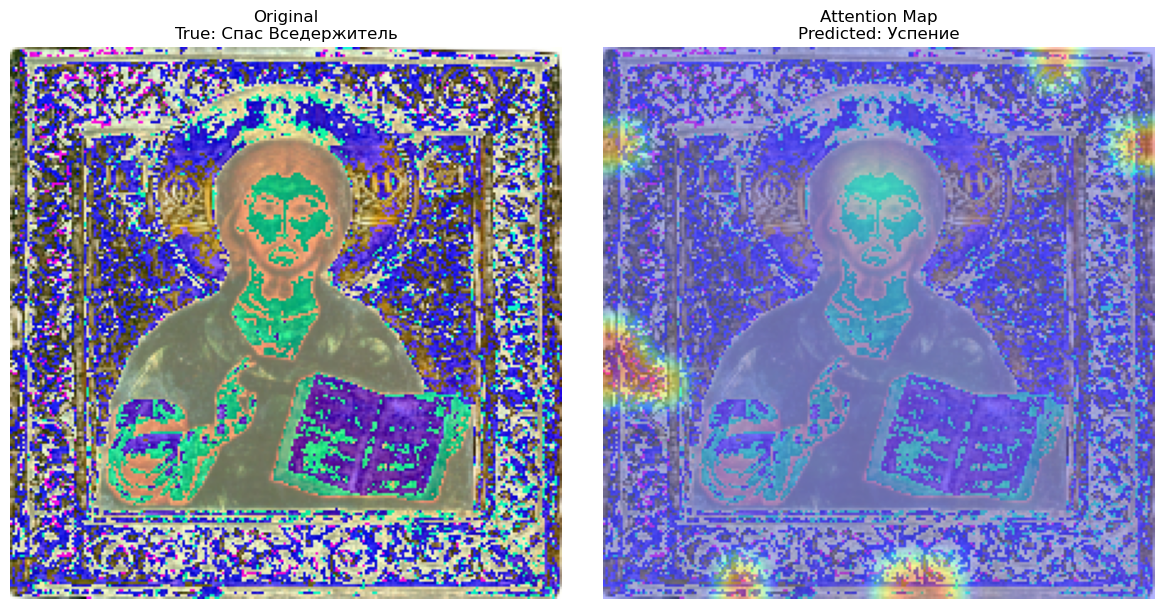

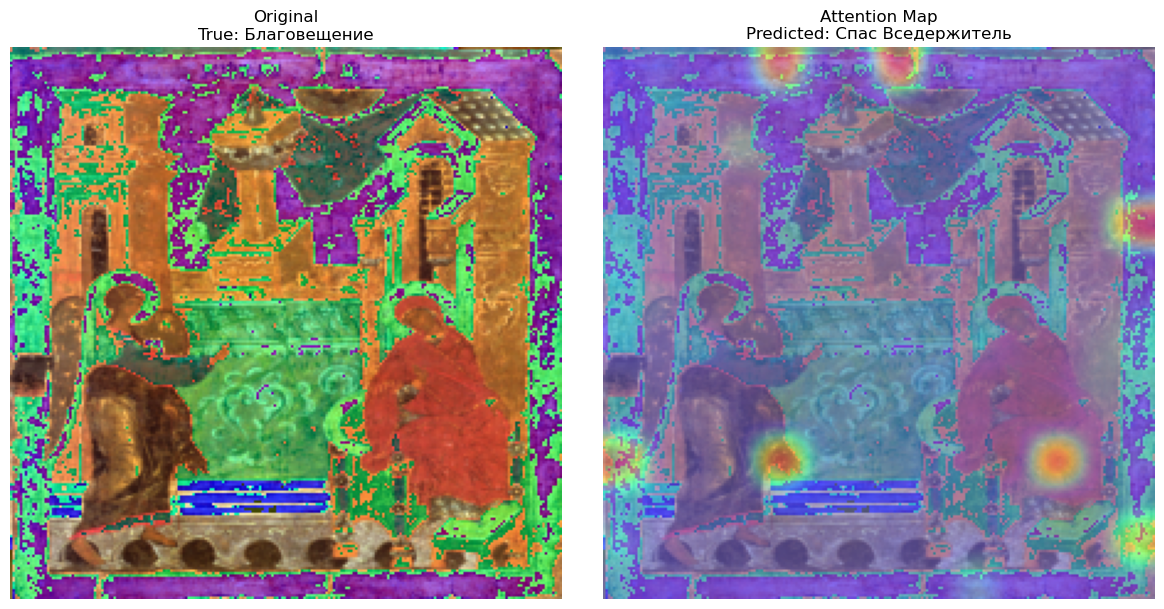

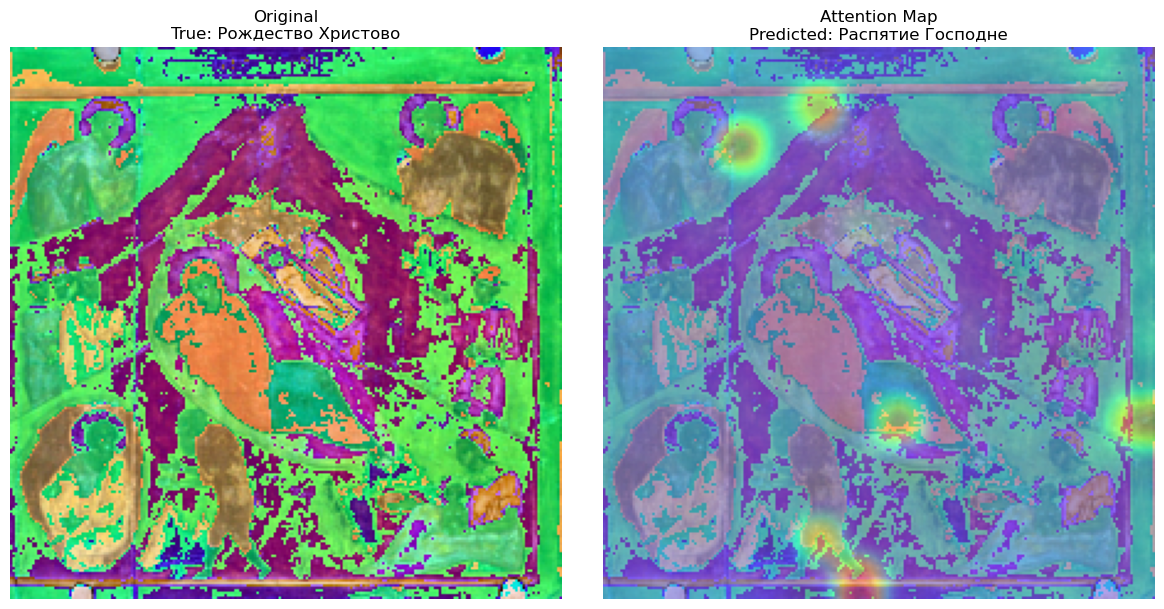

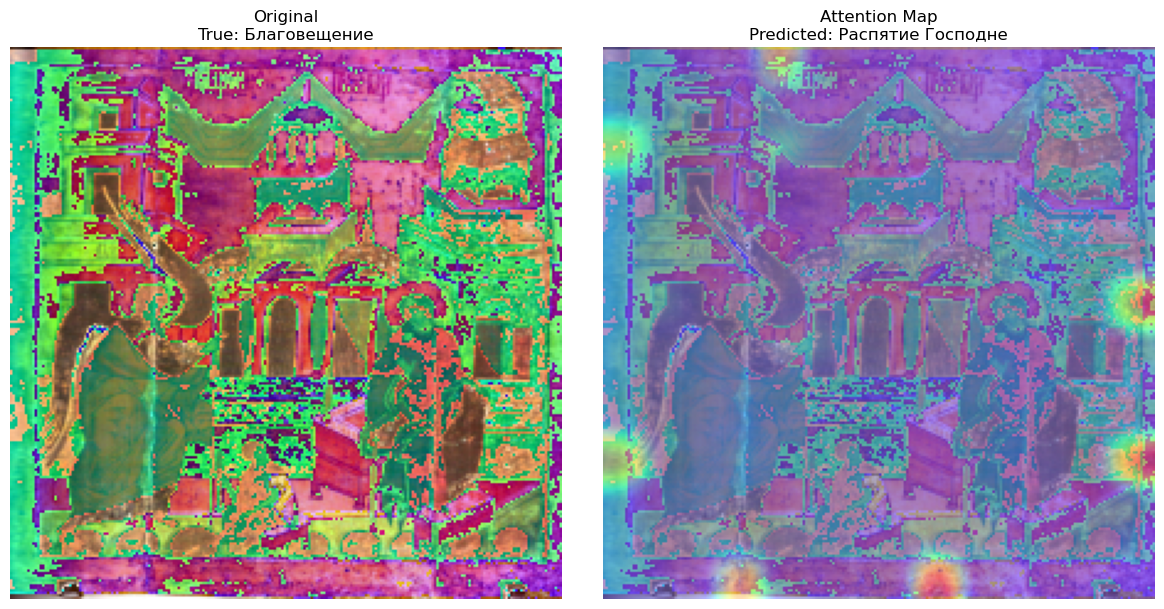

In [49]:
def visualize_vit_attention(model, img_tensor, label, label_encoder, head_idx=None):
    """
    Визуализация внимания ViT модели
    
    Параметры:
        model: ViT модель
        img_tensor: тензор изображения (C, H, W)
        label: истинная метка класса
        label_encoder: LabelEncoder для преобразования меток
        head_idx: индекс головы внимания (если None - усреднение по всем головам)
    """
    model.eval()
    
    # Подготовка входных данных
    input_tensor = img_tensor.unsqueeze(0).to(device)
    
    # Получаем выходы модели и внимания
    with torch.no_grad():
        outputs = model(input_tensor, output_attentions=True)
    
    # Получаем предсказанный класс
    pred_class = outputs.logits.argmax().item()
    
    # Получаем карты внимания из последнего слоя
    attentions = outputs.attentions[-1]  # [1, num_heads, num_patches+1, num_patches+1]
    
    # Усредняем по головам или выбираем конкретную
    if head_idx is not None:
        attention = attentions[0, head_idx]  # выбранная голова
    else:
        attention = attentions[0].mean(dim=0)  # усреднение по головам
    
    # Убираем внимание к [CLS] токену и нормализуем
    attention = attention[1:, 1:]  # [num_patches, num_patches]
    attention = attention.mean(dim=0)  # усредняем по всем патчам
    
    # Преобразуем в numpy
    attention = attention.cpu().numpy()
    
    # Вычисляем количество патчей
    num_patches = int(np.sqrt(len(attention)))
    
    # Решейпим в 2D карту
    attention_map = attention.reshape(num_patches, num_patches)
    
    # Подготовка изображения
    img = to_pil_image(img_tensor.cpu())
    img_size = img.size
    
    # Масштабируем карту внимания до размера изображения
    attention_map = np.array(Image.fromarray(attention_map).resize(img_size, Image.BICUBIC))
    
    # Нормализация
    attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
    
    # Визуализация
    plt.figure(figsize=(12, 6))
    
    # Оригинальное изображение
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Original\nTrue: {label_encoder.inverse_transform([label])[0]}")
    plt.axis('off')
    
    # Карта внимания
    plt.subplot(1, 2, 2)
    plt.imshow(img, alpha=0.7)
    plt.imshow(attention_map, cmap='jet', alpha=0.3)
    plt.title(f"Attention Map\nPredicted: {label_encoder.inverse_transform([pred_class])[0]}")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Пример использования
sample_img, sample_label = next(iter(test_loader))
for i in range(1, 5):  # посмотрим первые 5 примеров
    visualize_vit_attention(
        model, 
        sample_img[i].to(device), 
        sample_label[i].item(), 
        label_encoder,
        head_idx=None  # можно указать конкретную голову (0-11)
    )

In [2]:
# Посмотрим разные головы внимания для одного изображения
sample_img, sample_label = next(iter(test_loader))
img_idx = 1  # индекс изображения для анализа

for head in range(12):  # в ViT-base 12 голов
    visualize_vit_attention(
        model, 
        sample_img[img_idx].to(device), 
        sample_label[img_idx].item(), 
        label_encoder,
        head_idx=head
    )
    plt.suptitle(f"Head {head} attention", y=1.05)

NameError: name 'test_loader' is not defined

In [ ]:
---------------------------------------------------------------------

In [47]:
from torchcam.methods import GradCAMpp
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt
import torch
import numpy as np
from PIL import Image

def visualize_cam(model, img_tensor, label, label_encoder):
    """
    Визуализация карт активации для ViT модели
    
    Параметры:
        model: ViT модель
        img_tensor: тензор изображения (C, H, W)
        label: истинная метка класса
        label_encoder: LabelEncoder для преобразования меток
    """
    # Переводим модель в режим eval с градиентами
    model.eval()
    
    # Включаем градиенты для последнего слоя
    for param in model.vit.encoder.layer[-1].parameters():
        param.requires_grad = True
    
    # Инициализация GradCAM++
    cam_extractor = GradCAMpp(model, target_layer="vit.encoder.layer.11.attention.output")
    
    # Подготовка входных данных
    input_tensor = img_tensor.unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)
    
    try:
        # Forward pass
        out = model(input_tensor)
        
        # Получаем предсказанный класс
        pred_class = out.logits.argmax().item()
        
        # Генерация CAM
        activation_map = cam_extractor(pred_class, out.logits)
        
        # Подготовка изображения
        img = to_pil_image(img_tensor.cpu())
        img_size = img.size
        
        # Обработка карты активации
        cam = activation_map[0].squeeze(0).cpu().numpy()
        
        # Для ViT-Base (patch_size=16, img_size=224):
        # Количество патчей = 224/16 = 14 → 14x14=196
        # Но карта активации имеет размер 768 (это размерность эмбеддинга)
        # Нам нужно преобразовать это в 2D карту
        
        # Вариант 1: Берем среднее по эмбеддингам
        cam = cam.mean(axis=0) if len(cam.shape) > 1 else cam
        num_patches = int(np.sqrt(len(cam)))
        
        # Проверка возможности reshape
        if num_patches * num_patches != len(cam):
            print(f"Warning: Cannot reshape CAM of size {len(cam)} to square. Using interpolation.")
            # Создаем приближенную 2D карту
            side_length = int(np.ceil(np.sqrt(len(cam))))
            cam_2d = np.zeros(side_length * side_length)
            cam_2d[:len(cam)] = cam
            cam_2d = cam_2d.reshape(side_length, side_length)
            cam = cam_2d[:num_patches, :num_patches]  # Обрезаем до ближайшего квадрата
        
        else:
            cam = cam.reshape(num_patches, num_patches)
        
        # Масштабируем до размера изображения
        cam = np.array(Image.fromarray(cam).resize(img_size, Image.BICUBIC))
        
        # Нормализация
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        # Визуализация
        plt.figure(figsize=(12, 6))
        
        # Оригинальное изображение
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Original\nTrue: {label_encoder.inverse_transform([label])[0]}")
        plt.axis('off')
        
        # Карта активации
        plt.subplot(1, 2, 2)
        plt.imshow(img, alpha=0.7)
        plt.imshow(cam, cmap='jet', alpha=0.3)
        plt.title(f"Attention Heatmap\nPredicted: {label_encoder.inverse_transform([pred_class])[0]}")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
    finally:
        # Очистка
        cam_extractor.remove_hooks()
        input_tensor.requires_grad_(False)
        for param in model.vit.encoder.layer[-1].parameters():
            param.requires_grad = False


In [1]:
# Пример использования
sample_img, sample_label = next(iter(test_loader))
for i in range(1,30):
    visualize_cam(
        model, 
        sample_img[i].to(device), 
        sample_label[i].item(), 
        label_encoder
    )

NameError: name 'test_loader' is not defined